In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

# Load dataset
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a simple decision tree without tuning
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
print("Default Tree Accuracy:", accuracy_score(y_test, y_pred))


Default Tree Accuracy: 1.0


In [ ]:
#Effect of max_depth

In [3]:
for depth in [1, 2, 3, 5, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)
    print(f"Max Depth={depth}, Accuracy={accuracy_score(y_test, y_pred)}")


Max Depth=1, Accuracy=0.7111111111111111
Max Depth=2, Accuracy=0.9777777777777777
Max Depth=3, Accuracy=1.0
Max Depth=5, Accuracy=1.0
Max Depth=None, Accuracy=1.0


In [ ]:
#Compare results for different max_depth.

In [ ]:
#Q: At what depth does overfitting start to appear?
#Q: Which depth balances accuracy and simplicity?

In [ ]:
#Hyperparameter Tuning with GridSearch

In [4]:
param_grid = {
    'max_depth': [2, 3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                           param_grid, cv=5, scoring='accuracy')

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)


Best Parameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best Cross-Validation Accuracy: 0.9428571428571428


In [ ]:
#Run grid search.

#Record the best hyperparameters.

#Compare accuracy with the default tree.

In [ ]:
#Decision Tree Regression

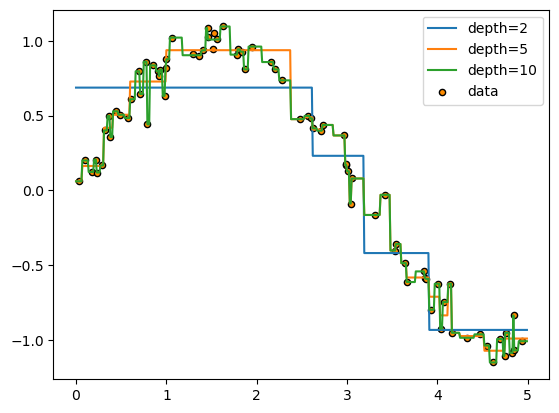

In [5]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

# Generate data
rng = np.random.RandomState(42)
X = np.sort(5 * rng.rand(80, 1), axis=0)
y = np.sin(X).ravel() + 0.1 * rng.randn(80)

# Fit regression trees with different depths
for depth in [2, 5, 10]:
    reg = DecisionTreeRegressor(max_depth=depth, random_state=42)
    reg.fit(X, y)

    X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
    y_pred = reg.predict(X_test)
    plt.plot(X_test, y_pred, label=f"depth={depth}")

plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.legend()
plt.show()


In [ ]:
#Observe how the regression curve changes with depth.
#At low depth: underfitting.

#At high depth: overfitting (too jagged).

#Q: Which depth generalizes best?